In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

pd.set_option('display.max_columns', None)

# Download dataset
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path dataset:", path)

# List contents of the downloaded directory to verify its structure
print("Contents of downloaded directory:", os.listdir(path))

# Load the single dataset file
df = pd.read_csv(os.path.join(path, "marketing_campaign.csv"), sep=None, engine="python", encoding="utf-8")

display(df.info())

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Path dataset: /kaggle/input/customer-personality-analysis
Contents of downloaded directory: ['marketing_campaign.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null 

None

# **1. Data Understanding**

In [3]:
# Numeric features
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [4]:
# Categorical features
df.describe(include=['object'])

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [5]:
# Count missing values
df.isnull().sum().to_frame().T

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,0,0,0,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Unique values per column
df.nunique().to_frame().T

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,2240,59,5,8,1974,3,3,663,100,776,158,558,182,177,213,15,15,14,14,16,2,2,2,2,2,2,1,1,2


# **2. Membersihkan Data**

## **2.1. Konversi Tipe Data**

In [7]:
# Convert to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

## **2.2. Fungsi Imputasi Missing Values**

In [8]:
def impute_numerical(df, columns, strategy="mean"):
    """
    Mengisi missing value pada kolom numerik.
    strategy: 'mean' atau 'median'
    """
    for col in columns:
        if df[col].isnull().any():
            if strategy == "mean":
                df[col] = df[col].fillna(df[col].mean())
            elif strategy == "median":
                df[col] = df[col].fillna(df[col].median())
    return df

def impute_categorical(df, columns):
    """
    Mengisi missing value pada kolom kategorikal menggunakan mode.
    """
    for col in columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

def impute_datetime(df, columns, strategy="mode", constant_date=None):
    """
    Mengisi missing value pada kolom datetime.

    strategy:
    - 'mode'  : nilai tanggal yang paling sering muncul
    - 'ffill' : forward fill
    - 'bfill' : backward fill
    - 'constant' : tanggal tetap (wajib isi constant_date)
    """
    for col in columns:
        if df[col].isnull().any():
            if strategy == "mode":
                df[col] = df[col].fillna(df[col].mode()[0])
            elif strategy == "ffill":
                df[col] = df[col].ffill()
            elif strategy == "bfill":
                df[col] = df[col].bfill()
            elif strategy == "constant":
                if constant_date is None:
                    raise ValueError("constant_date must be provided for 'constant' strategy")
                df[col] = df[col].fillna(pd.to_datetime(constant_date))
    return df

In [9]:
# Identifikasi kolom numerik dan kategorikal
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

df = impute_numerical(df, numerical_cols, strategy="mean")
df = impute_categorical(df, categorical_cols)
df = impute_datetime(df, ["Dt_Customer"], strategy="mode")

print("Missing values (numerical):")
display(df[numerical_cols].isnull().sum().to_frame().T)

print("Missing values (categorical):")
display(df[categorical_cols].isnull().sum().to_frame().T)

print(f"Missing values (datetime): {df['Dt_Customer'].isnull().sum()}")

Numerical columns: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
Categorical columns: ['Education', 'Marital_Status']
Missing values (numerical):


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Missing values (categorical):


,Education,Marital_Status
0,0,0


Missing values (datetime): 0


## **2.3. Statistik Setelah Imputasi**

In [10]:
print("Descriptive statistics after missing value imputation:")
display(df[numerical_cols].describe())
display(df[categorical_cols].describe(include=['object']))

Descriptive statistics after missing value imputation:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25037.797168,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51741.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,Education,Marital_Status
count,2240,2240
unique,5,8
top,Graduation,Married
freq,1127,864


# **3. Eksplorasi Data**

## **3.1. Distribusi**

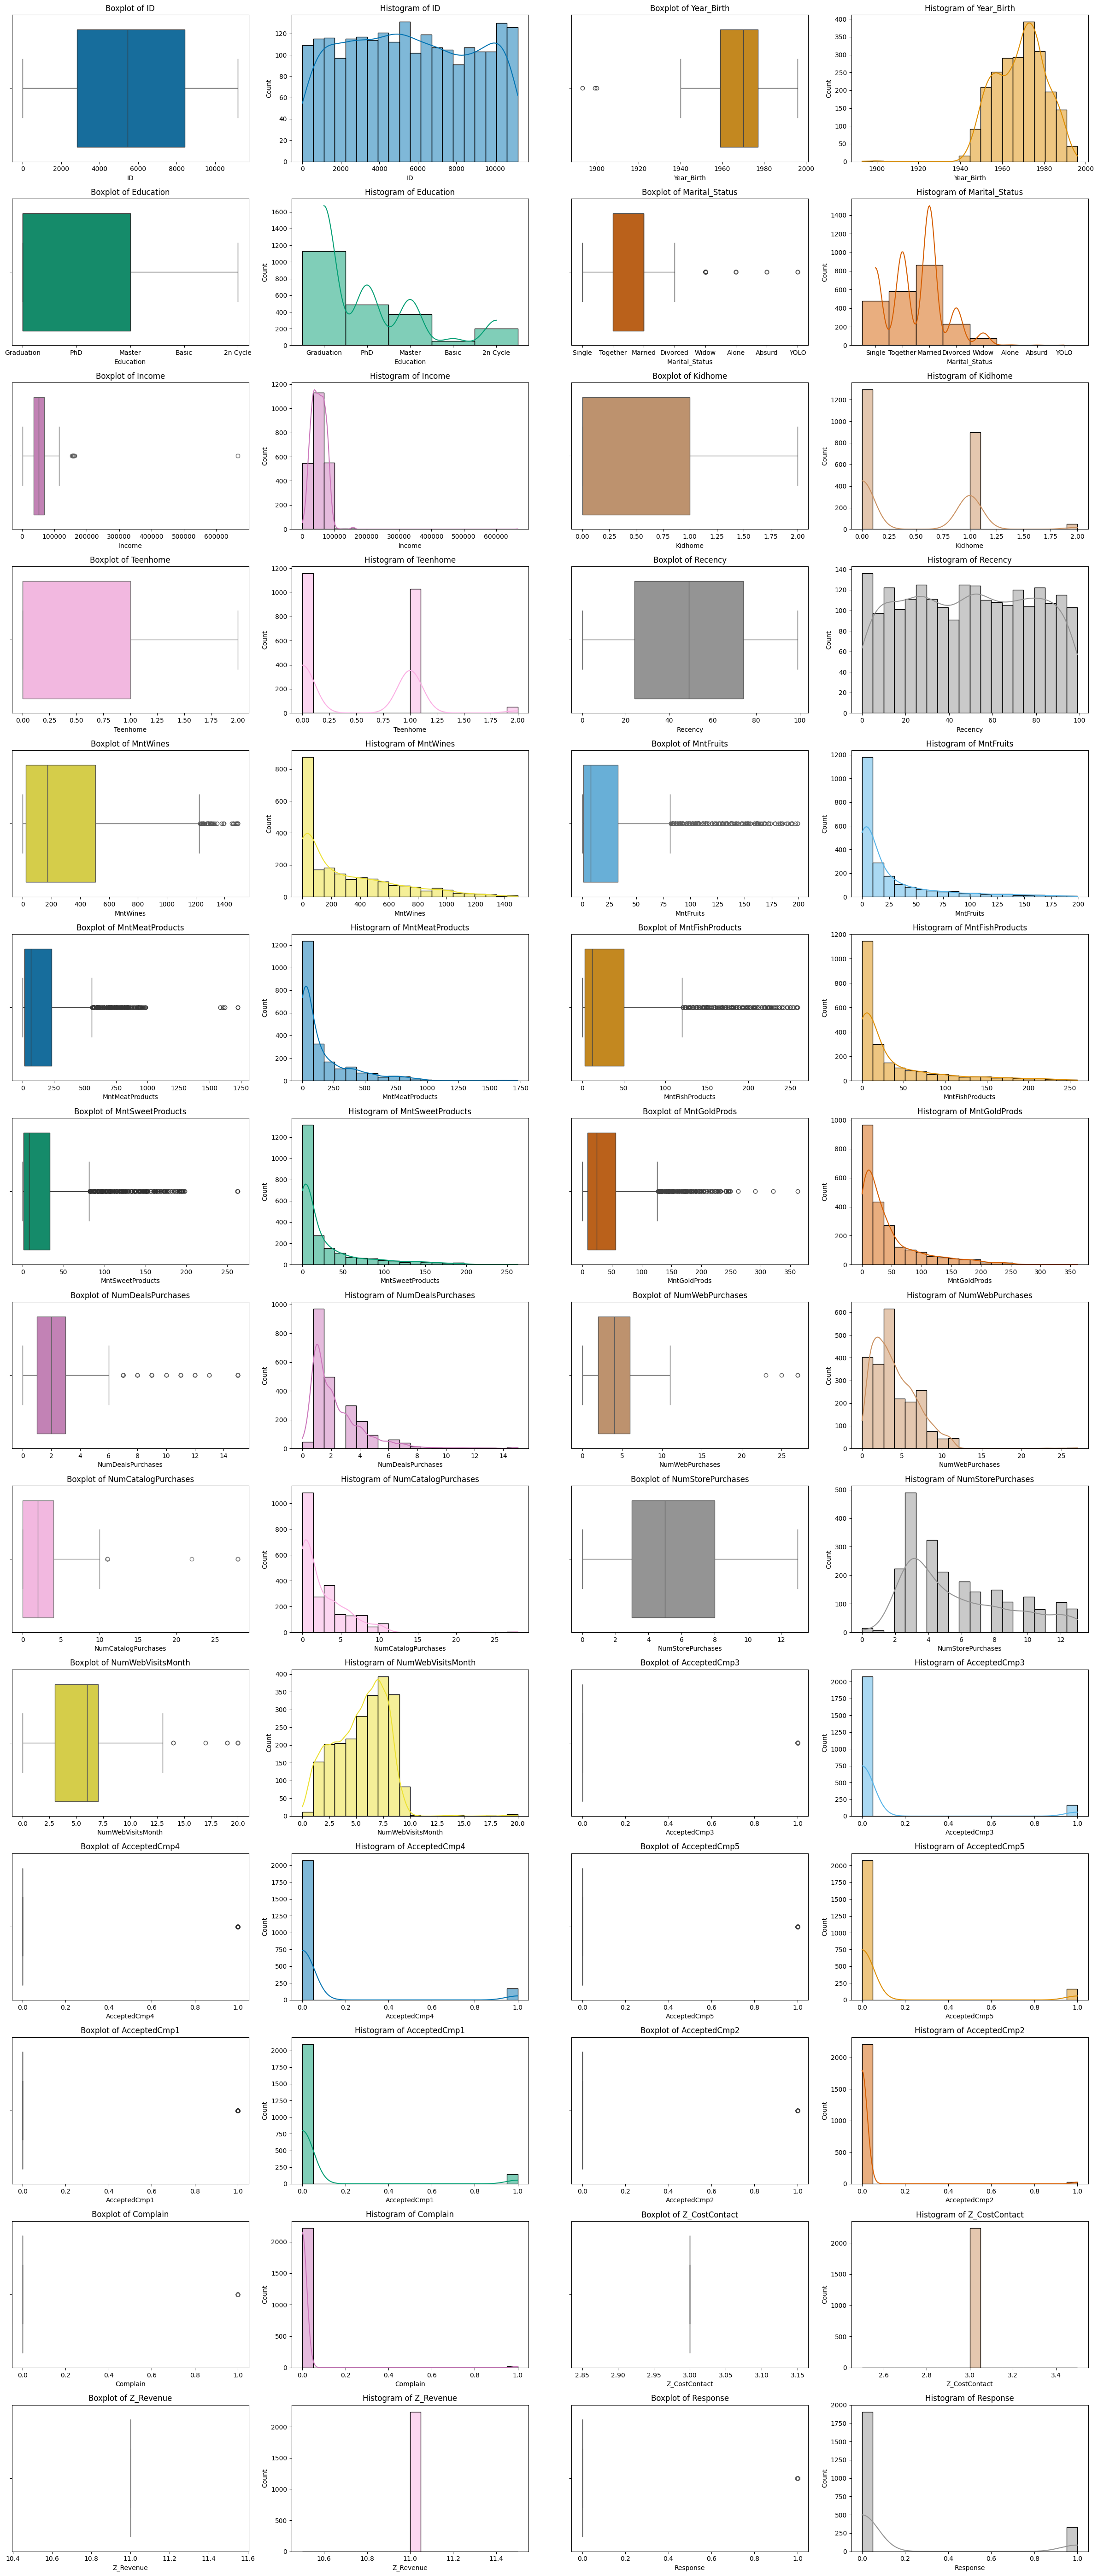

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numeric columns
num_cols = df.select_dtypes(include=['int32', 'int64', 'float64', 'object']).columns

# Assign color palette
colors = sns.color_palette('colorblind', n_colors=len(num_cols))

# Each feature uses 2 columns (box + hist) → total cols = 4
ncols = 4
nrows = (len(num_cols) * 2 + ncols - 1) // ncols  # round up

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

plot_idx = 0
for col, color in zip(num_cols, colors):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Boxplot of {col}')
    plot_idx += 1

    # Histogram
    sns.histplot(df[col], bins=20, kde=True, ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Histogram of {col}')
    plot_idx += 1

# Remove unused axes
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **3.1. Encoding**

In [12]:
from sklearn.preprocessing import LabelEncoder

def encode_object_columns(df):
    """
    Encode all object-type columns in a DataFrame to integers.
    Returns a new DataFrame with encoded columns and a dictionary of encoders.
    """
    df_encoded = df.copy()  # don't override original
    le_dict = {}

    obj_cols = df_encoded.select_dtypes(include='object').columns
    for col in obj_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le  # save encoder for inverse transform

    return df_encoded, le_dict

In [13]:
df_encoded, encoders = encode_object_columns(df)

display(df_encoded.head(5))

for col, encoder in encoders.items():
    print(f"Encoder for column '{col}': {encoder.classes_}")

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,2,4,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,2,4,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,2,5,71613.0,0,0,2012-12-09,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,2,5,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,4,3,58293.0,1,0,2012-12-09,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


Encoder for column 'Education': ['2n Cycle' 'Basic' 'Graduation' 'Master' 'PhD']
Encoder for column 'Marital_Status': ['Absurd' 'Alone' 'Divorced' 'Married' 'Single' 'Together' 'Widow' 'YOLO']


## **3.3. Korelasi**

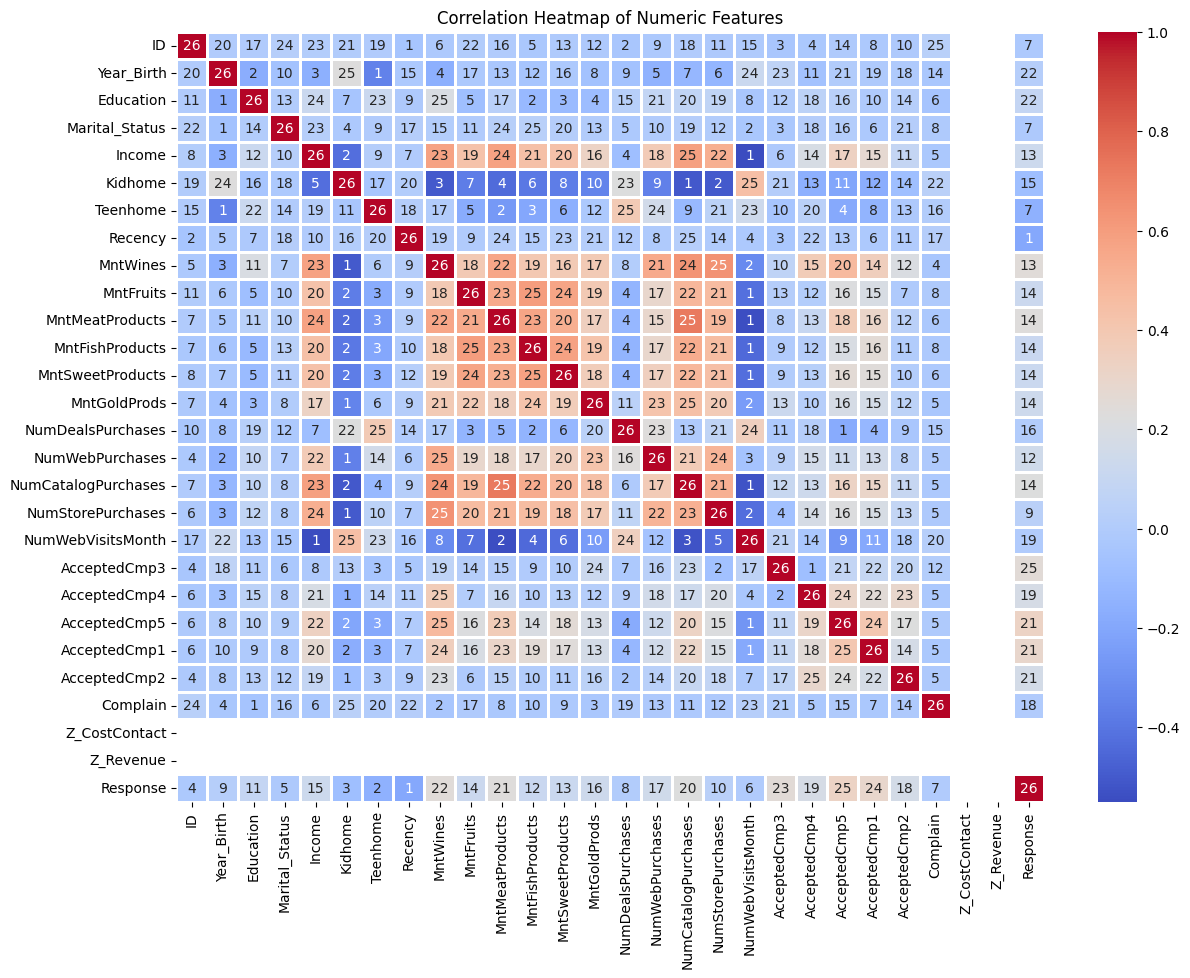

In [14]:
plt.figure(figsize=(14,10))
corr = df_encoded.select_dtypes(include=['float64','int64','int32']).corr()
sns.heatmap(corr, annot=corr.rank(axis='columns'), linewidth=1, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## **3.4. Pasangan**

Top correlated feature pairs:
 MntMeatProducts  NumCatalogPurchases    0.723827
MntWines         NumStorePurchases      0.642100
                 NumCatalogPurchases    0.635226
MntFruits        MntFishProducts        0.594804
Income           NumCatalogPurchases    0.586725
dtype: float64
Selected features for pairplot: ['MntWines', 'Income', 'MntMeatProducts', 'MntFishProducts', 'NumCatalogPurchases', 'NumStorePurchases', 'MntFruits']


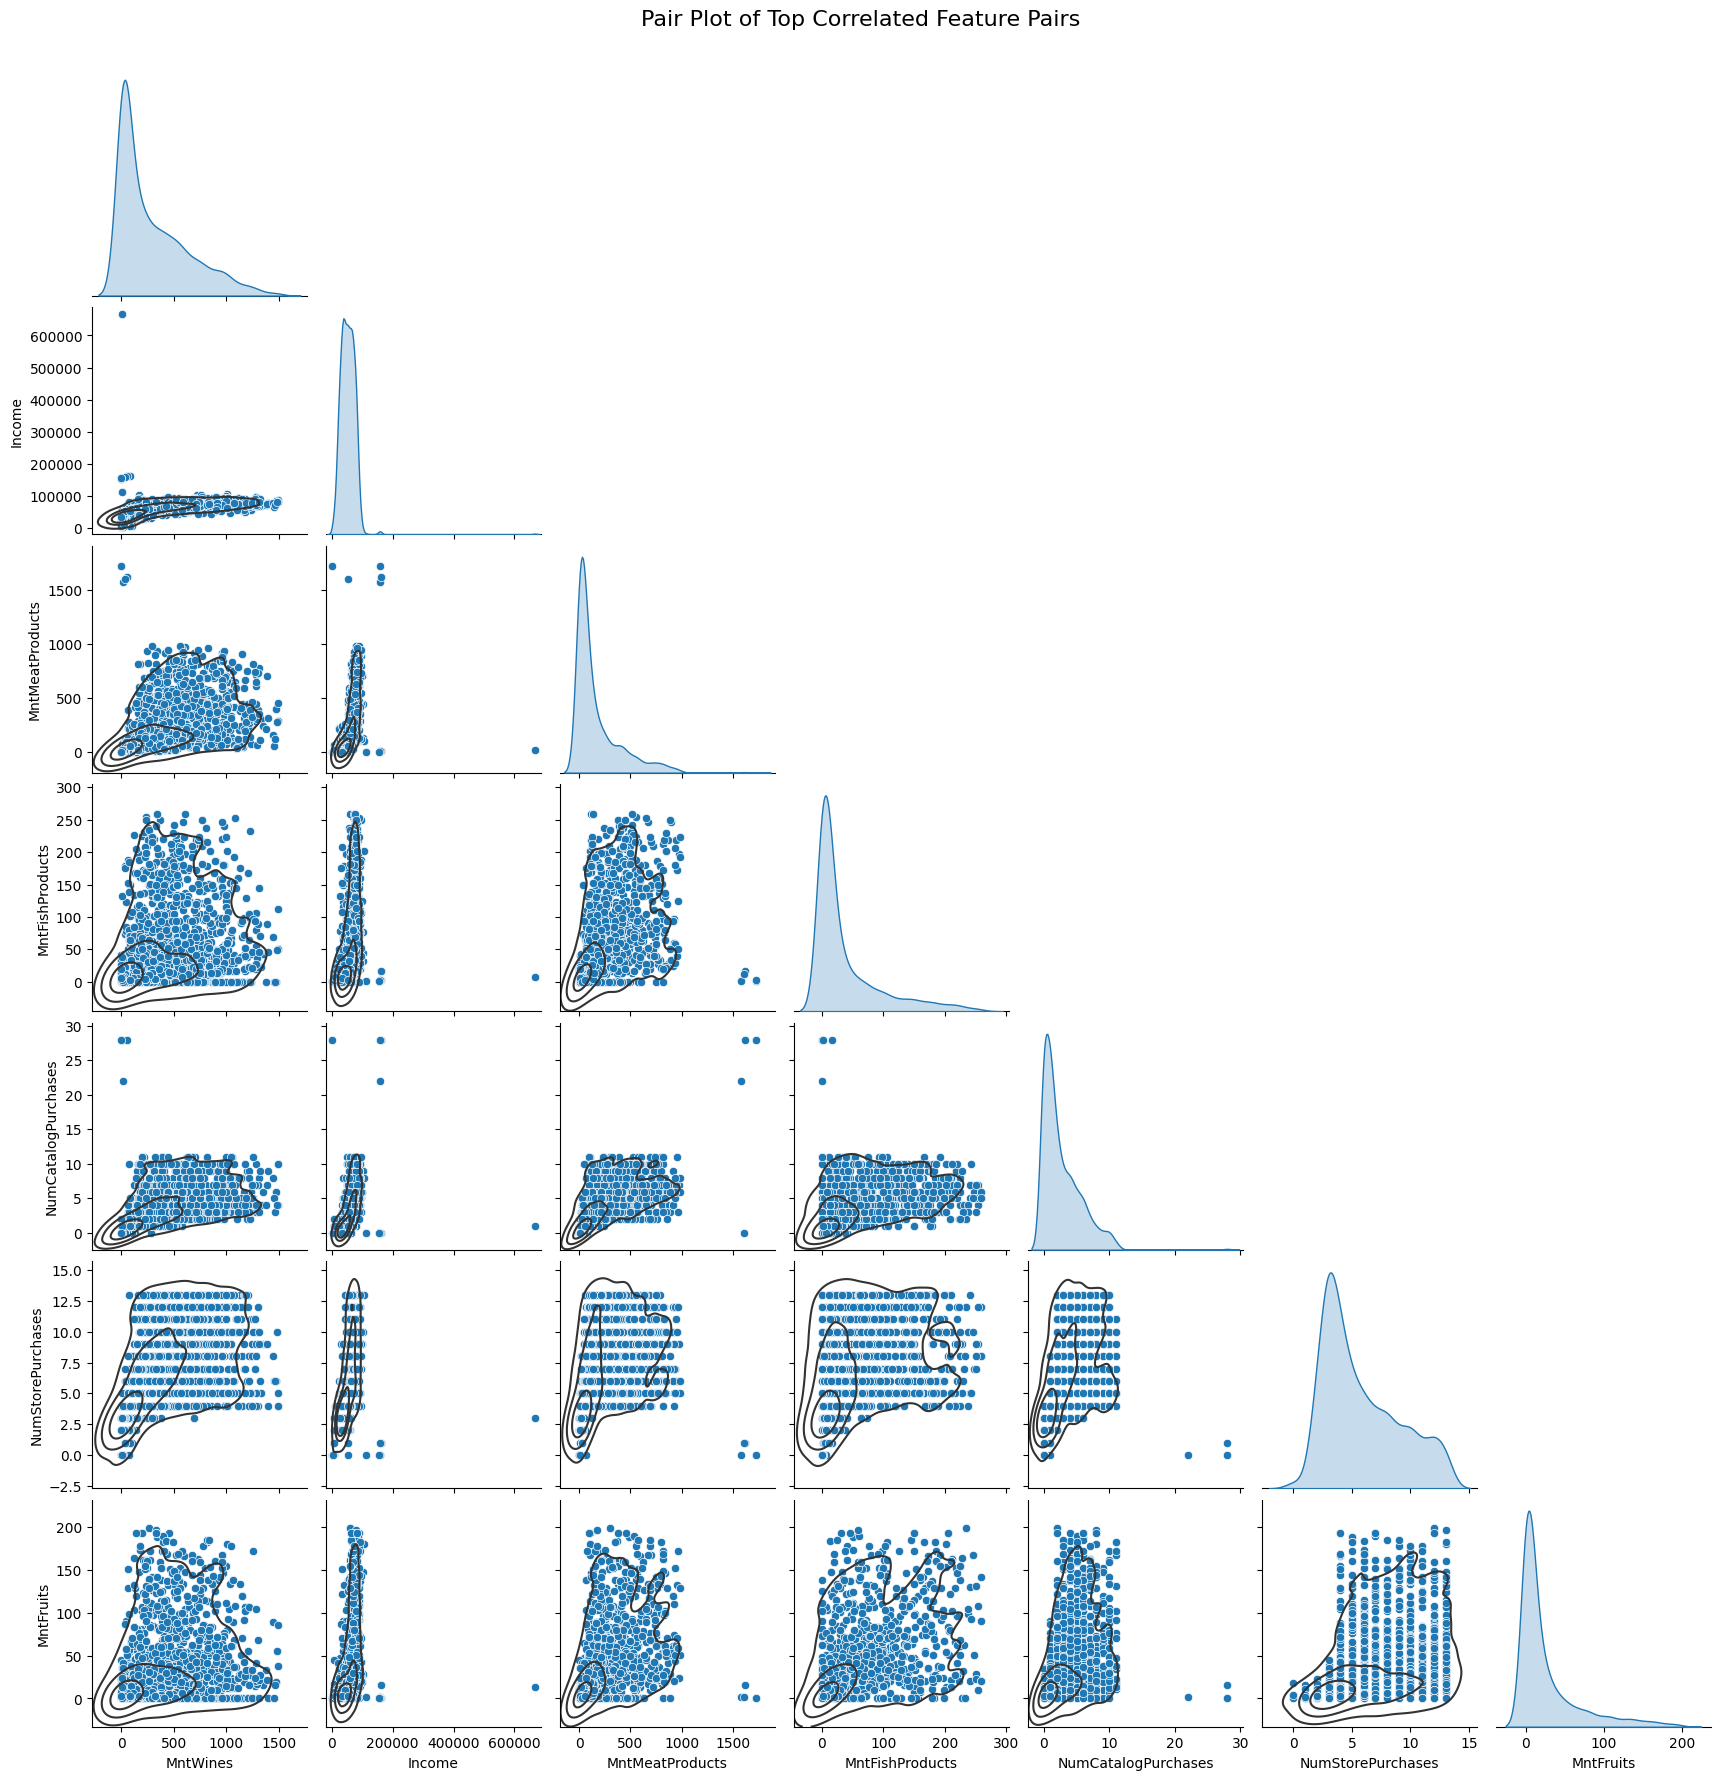

In [15]:
# --- Step 1: Compute correlation ---
corr = df_encoded.select_dtypes(include=['float64', 'int64', 'int32']).corr()

# --- Step 2: Find top N correlated pairs (excluding self-correlation) ---
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .sort_values(ascending=False)
)

top_n = 5  # number of pairs
print("Top correlated feature pairs:\n", corr_pairs.head(top_n))

# --- Step 3: Extract unique feature names from these pairs ---
top_features = list(set([col for pair in corr_pairs.head(top_n).index for col in pair]))
print("Selected features for pairplot:", top_features)

# --- Step 4: Pairplot ---
g = sns.pairplot(df_encoded[top_features], diag_kind="kde", corner=True)
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.suptitle('Pair Plot of Top Correlated Feature Pairs', y=1.02, fontsize=16)
plt.show()

# **4. Verifikasi Kualitas Data**

In [16]:
# 1️⃣ Fungsi untuk memeriksa konsistensi data
def check_data_consistency(df):
    """
    Memeriksa konsistensi data:
    - Tipe data tiap kolom
    - Proporsi missing value
    - Unik nilai tiap kolom (untuk kolom object)

    Returns: dictionary summary
    """
    consistency_report = {}

    for col in df.columns:
        consistency_report[col] = {
            'dtype': df[col].dtype,
            'missing_count': df[col].isnull().sum(),
            'missing_percent': round(df[col].isnull().mean() * 100, 2)
        }
        if df[col].dtype == 'object':
            consistency_report[col]['unique_values'] = df[col].nunique()

    return consistency_report


# 2️⃣ Fungsi untuk mendeteksi dan menangani duplikat
def detect_and_handle_duplicates(df, drop_duplicates=False):
    """
    Mendeteksi duplikat di DataFrame.
    Jika drop_duplicates=True, fungsi akan menghapus duplikat dan mengembalikan DataFrame baru.

    Returns:
        duplicate_report: dict dengan jumlah total duplikat
        df_cleaned: DataFrame baru tanpa duplikat jika drop_duplicates=True
    """
    duplicate_count = df.duplicated().sum()
    duplicate_report = {'total_duplicates': duplicate_count}

    if drop_duplicates:
        df_cleaned = df.drop_duplicates()
        return duplicate_report, df_cleaned
    else:
        return duplicate_report, df.copy()


# 3️⃣ Fungsi untuk memeriksa apakah nilai dalam kolom berada dalam rentang wajar
def check_value_ranges(df, column_ranges):
    """
    Memeriksa apakah nilai dalam kolom tertentu berada dalam rentang wajar.

    Args:
        df: DataFrame
        column_ranges: dict, format {'col_name': (min_value, max_value)}

    Returns:
        range_report: dict, berisi jumlah nilai yang berada di luar rentang untuk tiap kolom
    """
    range_report = {}

    for col, (min_val, max_val) in column_ranges.items():
        if col in df.columns:
            out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
            range_report[col] = {
                'out_of_range_count': len(out_of_range),
                'total_count': len(df),
                'percentage': round(len(out_of_range)/len(df) * 100, 2)
            }
        else:
            range_report[col] = 'Column not found'

    return range_report

In [17]:
from pprint import pprint

# 1. Cek konsistensi
consistency = check_data_consistency(df)
display(pd.DataFrame(consistency).T)

# 2. Deteksi duplikat
duplicates, df_no_dup = detect_and_handle_duplicates(df, drop_duplicates=True)
pprint(duplicates)

# 3. Cek rentang nilai
column_ranges = {'radius_se': (0, 1)}
range_report = check_value_ranges(df, column_ranges)
pprint(range_report)

,dtype,missing_count,missing_percent,unique_values
ID,int64,0,0.0,NaN
Year_Birth,int64,0,0.0,NaN
Education,object,0,0.0,5
Marital_Status,object,0,0.0,8
Income,float64,0,0.0,NaN
Kidhome,int64,0,0.0,NaN
Teenhome,int64,0,0.0,NaN
Dt_Customer,datetime64[ns],0,0.0,NaN
Recency,int64,0,0.0,NaN
MntWines,int64,0,0.0,NaN


{'total_duplicates': np.int64(0)}
{'radius_se': 'Column not found'}


# **5. Kriteria Pemilihan Data**

In [18]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi data training dan testing
X = df.drop('Response', axis=1)
y = df['Response']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Menampilkan ukuran data training dan testing
print("Ukuran data training:", X_train.shape)
print("Ukuran data testing:", X_test.shape)

# Menampilkan distribusi kelas target pada data training dan testing
print("\nDistribusi kelas target pada data training:\n", y_train.value_counts())
print("\nDistribusi kelas target pada data testing:\n", y_test.value_counts())

Ukuran data training: (1792, 28)
Ukuran data testing: (448, 28)

Distribusi kelas target pada data training:
 Response
0    1525
1     267
Name: count, dtype: int64

Distribusi kelas target pada data testing:
 Response
0    381
1     67
Name: count, dtype: int64


# **6. Menentukan Attributes dan Records**

In [19]:
# Records (rows) dari data training
records_train = X_train.shape[0]
print("\nRecords (rows) data training:", records_train)

# Records (rows) dari data testing
records_test = X_test.shape[0]
print("\nRecords (rows) data testing:", records_test)


Records (rows) data training: 1792

Records (rows) data testing: 448


# **7. Penggabungan Dataset**

In [20]:
# Menggabungkan dataset dengan dirinya sendiri
merged_df = pd.concat([df, df], axis=0)

# Mengecek ukuran dataset yang digabungkan
print("Ukuran dataset yang digabungkan:")
display(merged_df.shape)

# Mengecek apakah ada duplikat setelah penggabungan
print("\nJumlah baris duplikat setelah penggabungan:")
display(merged_df.duplicated().sum())

# Mengecek tipe data setiap kolom
print("\nTipe data setiap kolom:")
display(merged_df.dtypes)

# Mengecek missing value pada dataset yang digabungkan
print("\nJumlah nilai kosong pada setiap kolom:")
display(merged_df.isnull().sum())

# Contoh formatting data:
merged_df.columns = [col.replace(' ', '_') for col in merged_df.columns]

# Menampilkan dataset yang sudah digabungkan dan diformat
print("\nDataset yang sudah digabungkan dan diformat:")
display(merged_df)

Ukuran dataset yang digabungkan:


(4480, 29)


Jumlah baris duplikat setelah penggabungan:


np.int64(2240)


Tipe data setiap kolom:


,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64



Jumlah nilai kosong pada setiap kolom:


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0



Dataset yang sudah digabungkan dan diformat:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2012-12-09,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2012-12-09,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2012-12-09,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-10-06,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2012-12-09,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2012-12-09,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
